In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path

---

# Convergence visualization

In [4]:
# Set the path to the folder containing calculation results
# Change this to point to your results folder
RESULTS_PATH = "data/conv_biharmonic_prod"
# RESULTS_PATH = "data/conv_biharmonic_max_prod"

In [5]:
# Find all conv_history.dat files
results_path = Path(RESULTS_PATH)
conv_files = list(results_path.glob("*/conv_history.dat"))

print(f"Found {len(conv_files)} convergence history files")
for f in conv_files:
    print(f"  - {f.parent.name}")

Found 8 convergence history files
  - gmres_diag_cuda_double_32_20260127_231310
  - gmres_mg_cuda_double_32_20260127_231313
  - jacobi_diag_cuda_float_32_20260127_231302
  - jacobi_mg_cuda_float_32_20260127_231305
  - gmres_diag_cuda_float_32_20260127_231308
  - gmres_mg_cuda_float_32_20260127_231311
  - jacobi_mg_cuda_double_32_20260127_231306
  - jacobi_diag_cuda_double_32_20260127_231303


In [6]:
# Parse folder name to extract parameters
def parse_folder_name(folder_name):
    """Parse folder name like 'jacobi_diag_cuda_float_32_20260127_181708' into parameters"""
    parts = folder_name.split('_')
    if len(parts) >= 5:
        solver = parts[0].lower()
        prec = parts[1].lower()
        arch = parts[2].lower()
        dtype = parts[3].lower()  # 'float' or 'double'
        size = int(parts[4])
        return solver, prec, arch, size, dtype
    return None

# Store data in dictionary: key = (solver, prec, arch, size), value = {dtype: (iterations, residuals)}
convergence_dict = {}

for conv_file in sorted(conv_files):
    folder_name = conv_file.parent.name
    params = parse_folder_name(folder_name)

    if params is None:
        print(f"Warning: Could not parse folder name: {folder_name}")
        continue

    solver, prec, arch, size, dtype = params
    key = (solver, prec, arch, size)

    # Read data
    try:
        data = np.loadtxt(conv_file)
        if data.ndim == 1:
            # Single row case
            iterations = np.array([data[0]])
            residuals = np.array([data[1]])
        else:
            iterations = data[:, 0]
            residuals = data[:, 1]

        # Downsample if needed (every 3rd point)
        if len(iterations) > 20:
            factor = 10
        elif len(iterations) > 10:
            factor = 2
        else:
            factor = 0

        if factor != 0:
            # print('before:', iterations)
            # print(len(iterations))
            # print((len(iterations)//factor)*factor)
            idx = list(range(0, (len(iterations)//factor)*factor, factor))
            if len(iterations) % factor != 0:
                idx.append(len(iterations)-1)

            iterations_downsample = iterations[idx]
            residuals_downsample = residuals[idx]
            # residuals_downsample = residuals[:((len(residuals)//factor)*factor):factor]
        else:
            iterations_downsample = iterations.copy()
            residuals_downsample = residuals.copy()
        # iterations, residuals = downsample_data(iterations, residuals, factor=1)

        # Initialize nested dict if key doesn't exist
        if key not in convergence_dict:
            convergence_dict[key] = {}

        convergence_dict[key][dtype] = (iterations_downsample, residuals_downsample)
        print(f"Loaded: {solver} + {prec} ({arch}, {dtype}, N={size}) - {len(iterations)} points")
    except Exception as e:
        print(f"Error reading {conv_file}: {e}")

print(f"\nTotal configurations: {len(convergence_dict)}")

Loaded: gmres + diag (cuda, double, N=32) - 148 points
Loaded: gmres + diag (cuda, float, N=32) - 73 points
Loaded: gmres + mg (cuda, double, N=32) - 10 points
Loaded: gmres + mg (cuda, float, N=32) - 6 points
Loaded: jacobi + diag (cuda, double, N=32) - 151 points
Loaded: jacobi + diag (cuda, float, N=32) - 151 points
Loaded: jacobi + mg (cuda, double, N=32) - 18 points
Loaded: jacobi + mg (cuda, float, N=32) - 9 points

Total configurations: 4


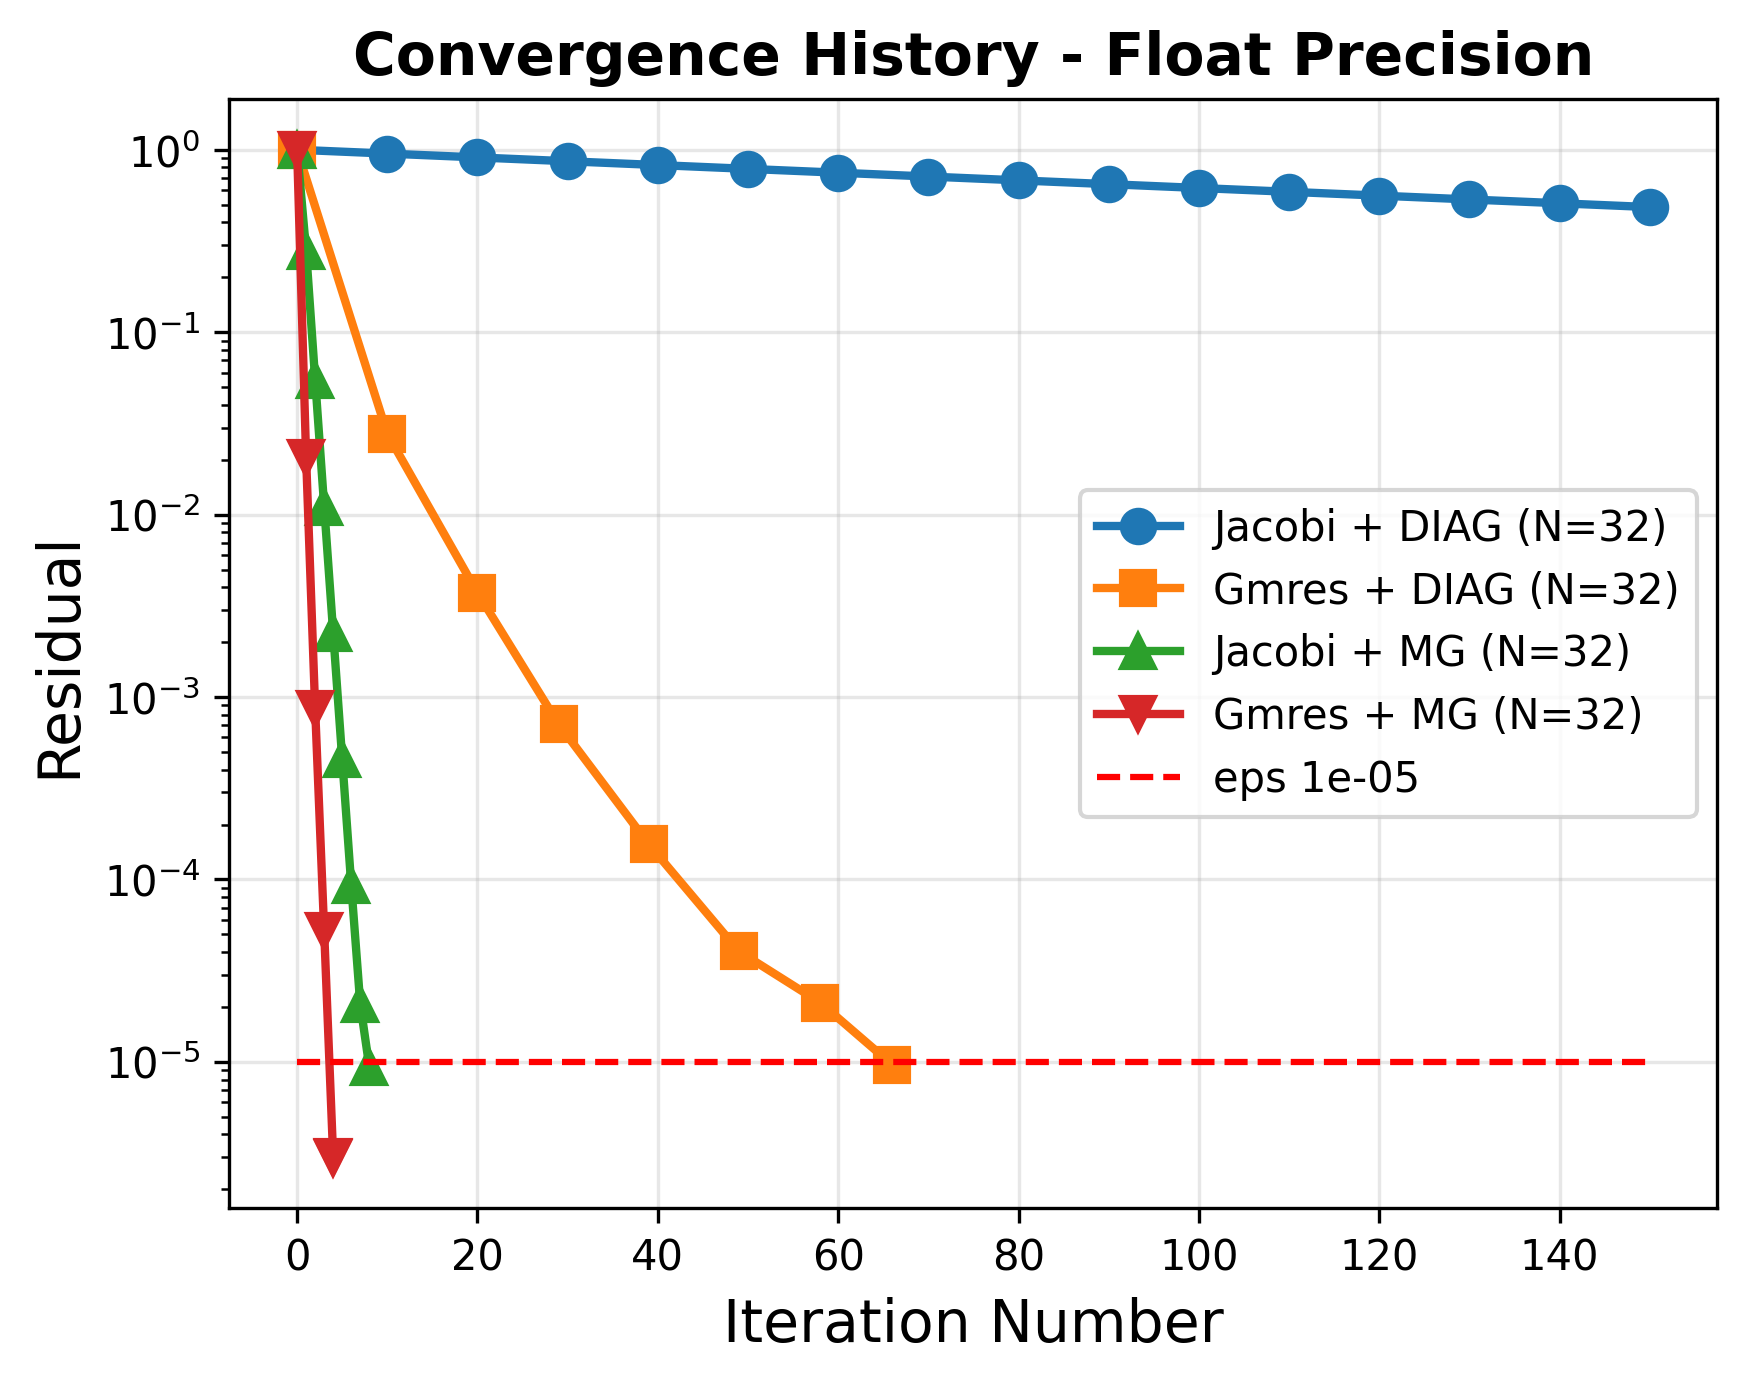

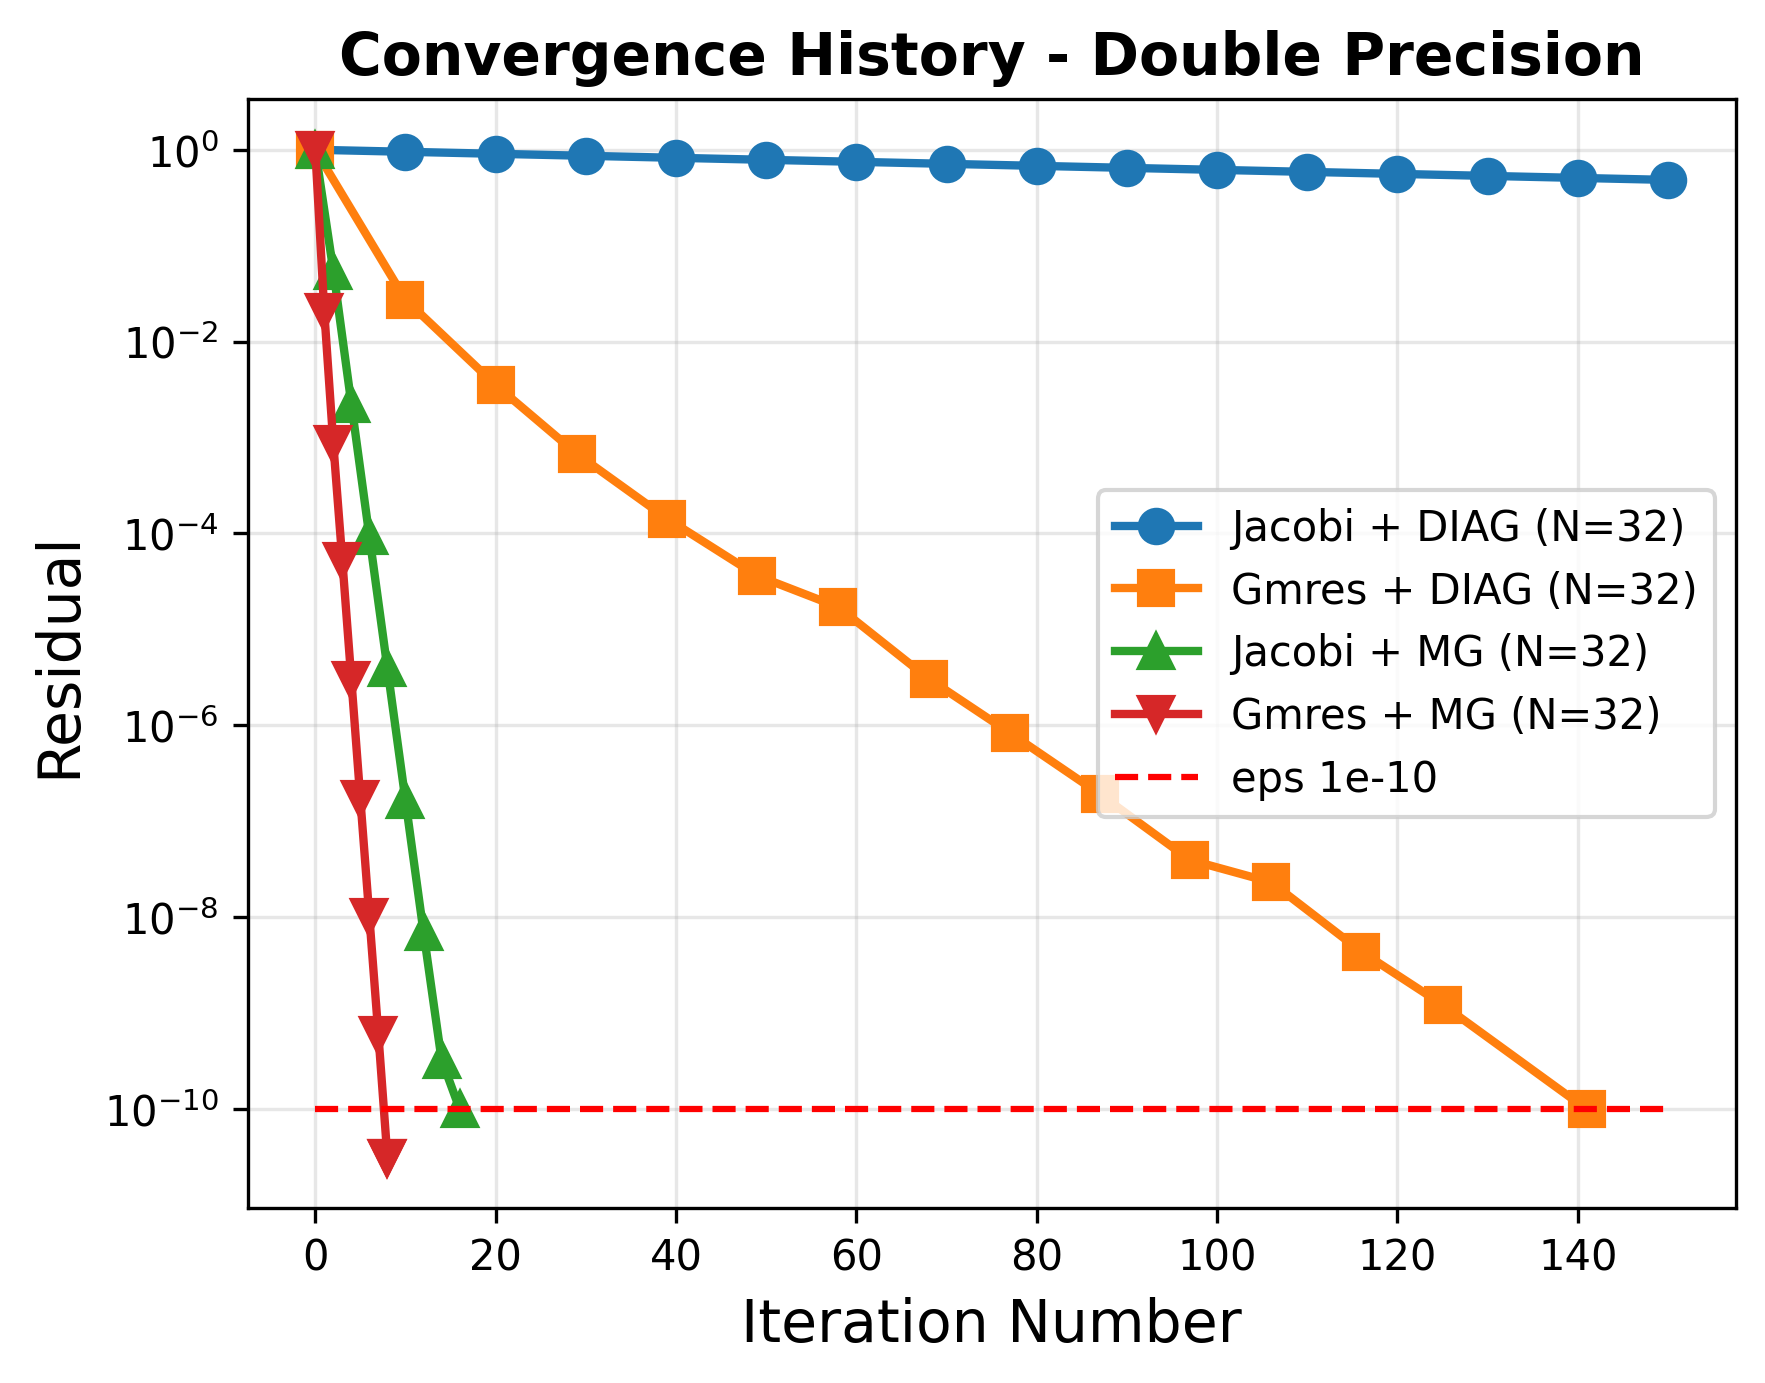

In [7]:
# Define markers and colors for different configurations
markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h', 'X', 'P']
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Create plots for each precision type
for precision in ['float', 'double']:
    scale=0.8
    fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

    # Prepare data with iteration counts for sorting
    plot_data = []
    for key, data_dict in convergence_dict.items():
        solver, prec, arch, size = key

        # Check if this precision exists for this configuration
        if precision not in data_dict:
            continue

        iterations, residuals = data_dict[precision]
        num_iterations = iterations[-1]

        plot_data.append((key, iterations, residuals, num_iterations))

    # Sort by number of iterations (descending - most iterations first)
    plot_data.sort(key=lambda x: x[3], reverse=True)

    marker_idx = 0
    for key, iterations, residuals, num_iterations in plot_data:
        solver, prec, arch, size = key

        # Create label
        label = f"{solver.capitalize()} + {prec.upper()} (N={size})"

        # Get marker and color
        marker = markers[marker_idx % len(markers)]
        color = colors[marker_idx % len(colors)]
        marker_idx += 1

        # Plot with markers
        ax.plot(
            iterations, residuals,
            marker=marker,
            color=color,
            label=label,
            markersize=8,
            linewidth=2
        )

    # Add horizontal line for convergence tolerance with label
    tolerance = 1e-10 if precision == 'double' else 1e-5
    tolerance_label = f'eps {tolerance:.0e}'
    ax.hlines(tolerance, 0, 150, linewidth=1.5, linestyles='--', color='red', label=tolerance_label)

    ax.set_xlabel('Iteration Number', fontsize=14)
    ax.set_ylabel('Residual', fontsize=14)
    ax.set_title(f'Convergence History - {precision.capitalize()} Precision', fontsize=14, fontweight='bold')
    ax.legend(loc='center right', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Set log scale only on y-axis (base 10)
    ax.set_yscale('log', base=10)

    # Format y-axis ticks (powers of 10)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.tick_params(axis='both', which='minor', labelsize=10)

    # plt.tight_layout()
    plt.show()

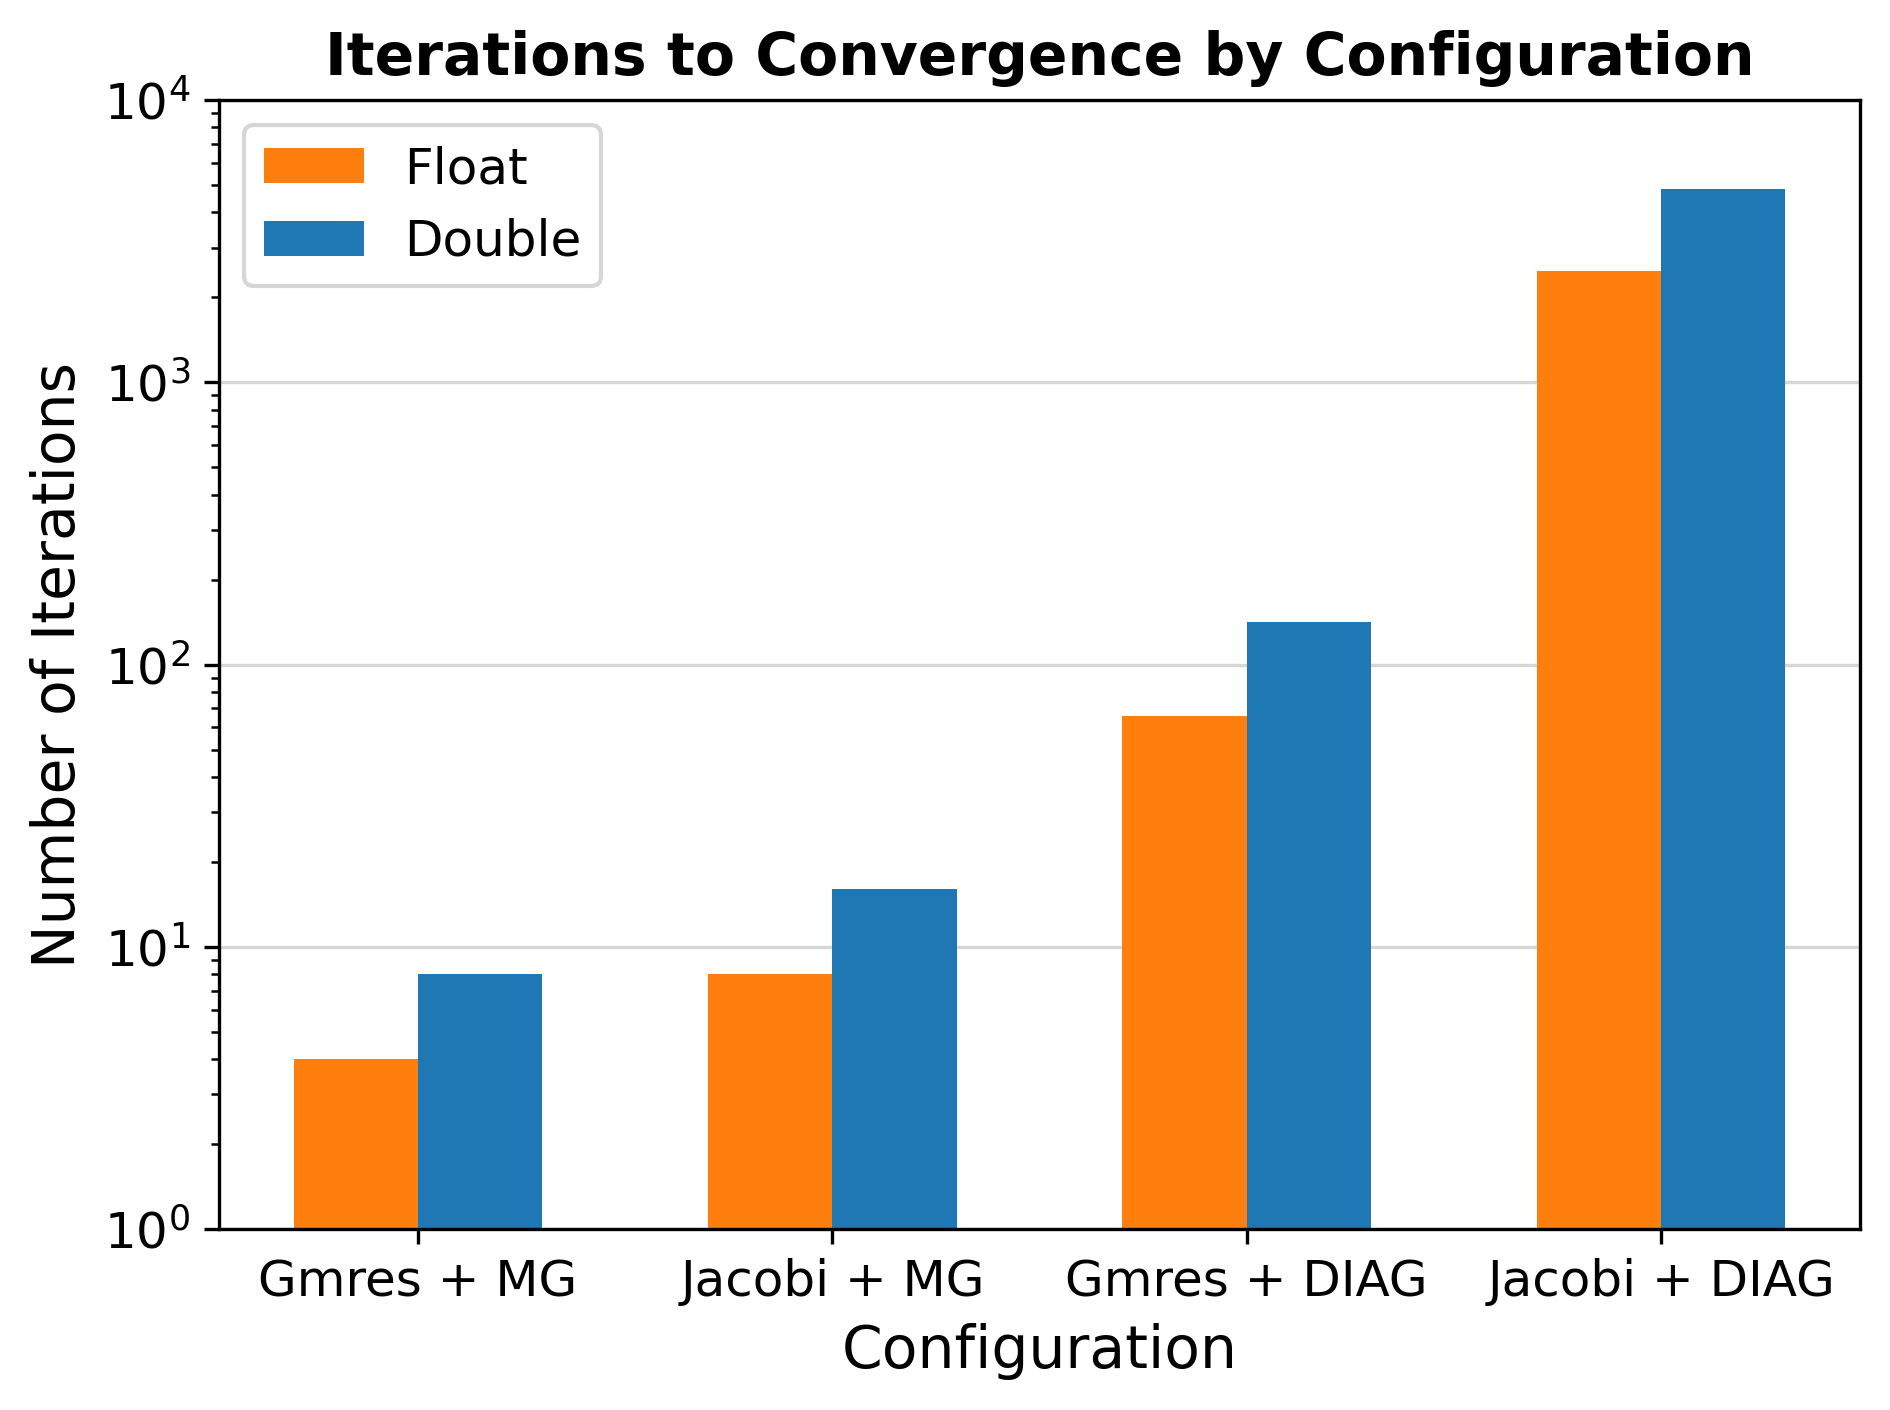

In [54]:
# Bar plot: Number of iterations by configuration
# Configuration parameters
bar_width = 0.3  # Width of each bar
bar_offset = 0.15  # Offset from tick position (positive = right, negative = left)

scale = 0.8
fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Collect iteration counts for each configuration (solver + preconditioner)
config_data = []  # List of (config_name, float_iterations, double_iterations, avg_iterations)

for key, data_dict in convergence_dict.items():
    solver, prec, arch, size = key

    float_iterations = None
    double_iterations = None

    if 'float' in data_dict:
        iterations, residuals = data_dict['float']
        float_iterations = int(iterations[-1])

    if 'double' in data_dict:
        iterations, residuals = data_dict['double']
        double_iterations = int(iterations[-1])

    # Calculate average for sorting (use available values)
    avg_iterations = 0
    count = 0
    if float_iterations is not None:
        avg_iterations += float_iterations
        count += 1
    if double_iterations is not None:
        avg_iterations += double_iterations
        count += 1
    if count > 0:
        avg_iterations = avg_iterations / count
    else:
        continue  # Skip if no data

    # Create configuration label
    config_name = f"{solver.capitalize()} + {prec.upper()}"

    config_data.append((config_name, float_iterations, double_iterations, avg_iterations))

# Sort by average iterations (ascending - minimum on left, maximum on right)
config_data.sort(key=lambda x: x[3])

# Extract sorted data
config_names = [item[0] for item in config_data]
float_values = [item[1] for item in config_data]
double_values = [item[2] for item in config_data]

# Create x positions for bars
x_pos = np.arange(len(config_names))

# Calculate bar positions
float_positions = x_pos - bar_offset
double_positions = x_pos + bar_offset

# Plot bars
float_bars = ax.bar(float_positions, float_values, bar_width,
                    label='Float', color=colors[1], zorder=2)
double_bars = ax.bar(double_positions, double_values, bar_width,
                     label='Double', color=colors[0], zorder=2)

# Set labels and title
ax.set_xlabel('Configuration', fontsize=14)
ax.set_ylabel('Number of Iterations', fontsize=14)
ax.set_title('Iterations to Convergence by Configuration', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(config_names, fontsize=12)
# ax.set_нticklabels([], fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.5, axis='y', zorder=1)

# Set log scale on y-axis
ax.set_yscale('log', base=10)

# Set specific Y-axis ticks: 10^0, 10^1, 10^2, 10^4
y_ticks = [10**0, 10**1, 10**2, 10**3, 10**4]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'$10^{{{int(np.log10(t))}}}$' for t in y_ticks], fontsize=12)

# Format ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=12)

plt.tight_layout()
plt.show()

---

# Grid Size Experiment Visualization

This section visualizes how the number of iterations required for convergence depends on grid size.

In [2]:
# Set the base path for grid size experiments
# This should point to the folder containing grid size subdirectories (data/2/, data/4/, etc.)
GRID_SIZE_BASE_PATH = "data/conv_biharmonic_grid_prod"

# Find all grid size directories
base_path = Path(GRID_SIZE_BASE_PATH)
grid_size_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.isdigit()]

print(f"Found {len(grid_size_dirs)} grid size directories:")
for d in sorted(grid_size_dirs, key=lambda x: int(x.name)):
    print(f"  - {d.name}")

Found 8 grid size directories:
  - 2
  - 4
  - 8
  - 16
  - 32
  - 64
  - 128
  - 256


In [3]:
# Parse folder name to extract parameters
def parse_folder_name(folder_name):
    """Parse folder name like 'jacobi_diag_cuda_float_32_20260127_181708' into parameters"""
    parts = folder_name.split('_')
    if len(parts) >= 5:
        solver = parts[0].lower()
        prec = parts[1].lower()
        arch = parts[2].lower()
        dtype = parts[3].lower()  # 'float' or 'double'
        size = int(parts[4])
        return solver, prec, arch, size, dtype
    return None

# Function to check if calculation converged by reading log file
def check_convergence(log_file_path):
    """Check if calculation converged by reading log file"""
    try:
        with open(log_file_path, 'r') as f:
            content = f.read()
            # Look for "Converged: yes" or "Converged: no"
            if "Converged:                  yes" in content:
                return True
            elif "Converged:                  no" in content:
                return False
            # Also check for ERROR messages
            if "ERROR:" in content and "failed to converge" in content:
                return False
    except Exception as e:
        print(f"Warning: Could not read log file {log_file_path}: {e}")
        return False
    return None  # Unknown status

# Store data: key = (solver, prec, arch), value = {dtype: {grid_size: iterations}}
grid_size_dict = {}

for grid_size_dir in sorted(grid_size_dirs, key=lambda x: int(x.name)):
    grid_size = int(grid_size_dir.name)

    # Look for conv_biharmonic_prod subdirectory
    conv_prod_dir = grid_size_dir
    if not conv_prod_dir.exists():
        print(f"Warning: {conv_prod_dir} does not exist, skipping grid size {grid_size}")
        continue

    # Find all conv_history.dat files in this grid size
    conv_files = list(conv_prod_dir.glob("*/conv_history.dat"))

    for conv_file in sorted(conv_files):
        folder_name = conv_file.parent.name
        params = parse_folder_name(folder_name)

        if params is None:
            print(f"Warning: Could not parse folder name: {folder_name}")
            continue

        solver, prec, arch, size_from_name, dtype = params

        # Verify grid size matches
        if size_from_name != grid_size:
            print(f"Warning: Grid size mismatch in {folder_name}: expected {grid_size}, got {size_from_name}")
            continue

        # Check convergence status
        log_file = conv_file.parent / "log.txt"
        converged = check_convergence(log_file)

        if converged is False:
            print(f"SKIPPING (not converged): {solver} + {prec} ({dtype}, N={grid_size})")
            continue
        elif converged is None:
            print(f"WARNING (unknown status): {solver} + {prec} ({dtype}, N={grid_size})")
            # Continue anyway, but warn

        # Read convergence history
        try:
            data = np.loadtxt(conv_file)
            if data.ndim == 1:
                iterations = np.array([data[0]])
            else:
                iterations = data[:, 0]

            # Get final iteration number
            final_iteration = int(iterations[-1])

            # Store in dictionary
            key = (solver, prec, arch)
            if key not in grid_size_dict:
                grid_size_dict[key] = {}
            if dtype not in grid_size_dict[key]:
                grid_size_dict[key][dtype] = {}

            grid_size_dict[key][dtype][grid_size] = final_iteration
            print(f"Loaded: {solver} + {prec} ({dtype}, N={grid_size}) - {final_iteration} iterations")

        except Exception as e:
            print(f"Error reading {conv_file}: {e}")

print(f"\nTotal configurations: {len(grid_size_dict)}")

Loaded: gmres + diag (double, N=2) - 2 iterations
Loaded: gmres + diag (float, N=2) - 2 iterations
Loaded: gmres + mg (double, N=2) - 2 iterations
Loaded: gmres + mg (float, N=2) - 1 iterations
Loaded: jacobi + diag (double, N=2) - 22 iterations
Loaded: jacobi + diag (float, N=2) - 10 iterations
Loaded: jacobi + mg (double, N=2) - 3 iterations
Loaded: jacobi + mg (float, N=2) - 2 iterations
Loaded: gmres + diag (double, N=4) - 8 iterations
Loaded: gmres + diag (float, N=4) - 6 iterations
Loaded: gmres + mg (double, N=4) - 4 iterations
Loaded: gmres + mg (float, N=4) - 3 iterations
Loaded: jacobi + diag (double, N=4) - 74 iterations
Loaded: jacobi + diag (float, N=4) - 32 iterations
Loaded: jacobi + mg (double, N=4) - 8 iterations
Loaded: jacobi + mg (float, N=4) - 4 iterations
Loaded: gmres + diag (double, N=8) - 23 iterations
Loaded: gmres + diag (float, N=8) - 12 iterations
Loaded: gmres + mg (double, N=8) - 6 iterations
Loaded: gmres + mg (float, N=8) - 3 iterations
Loaded: jacobi +

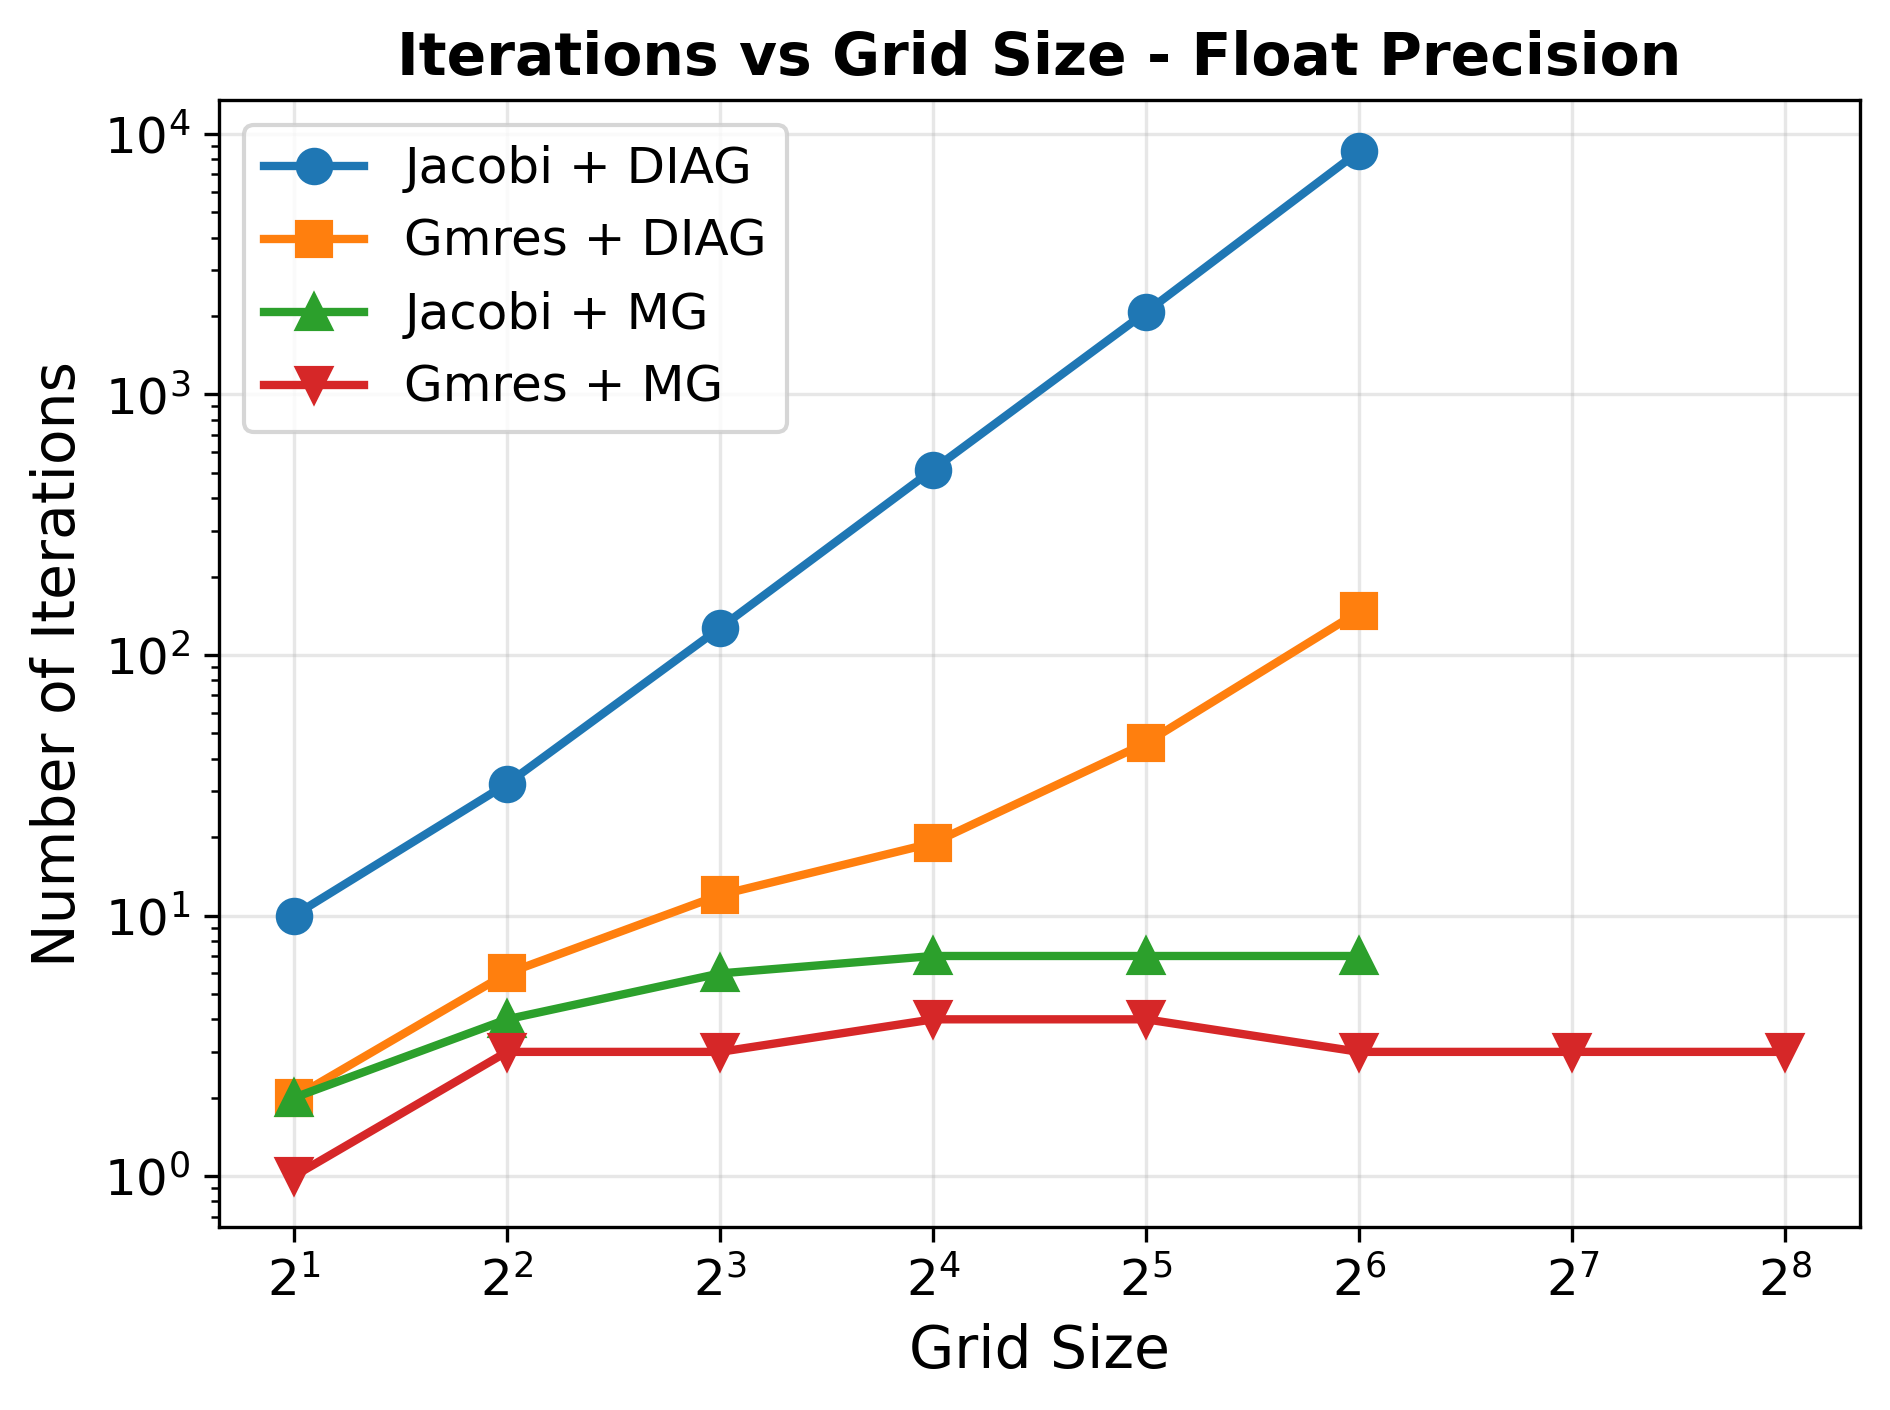

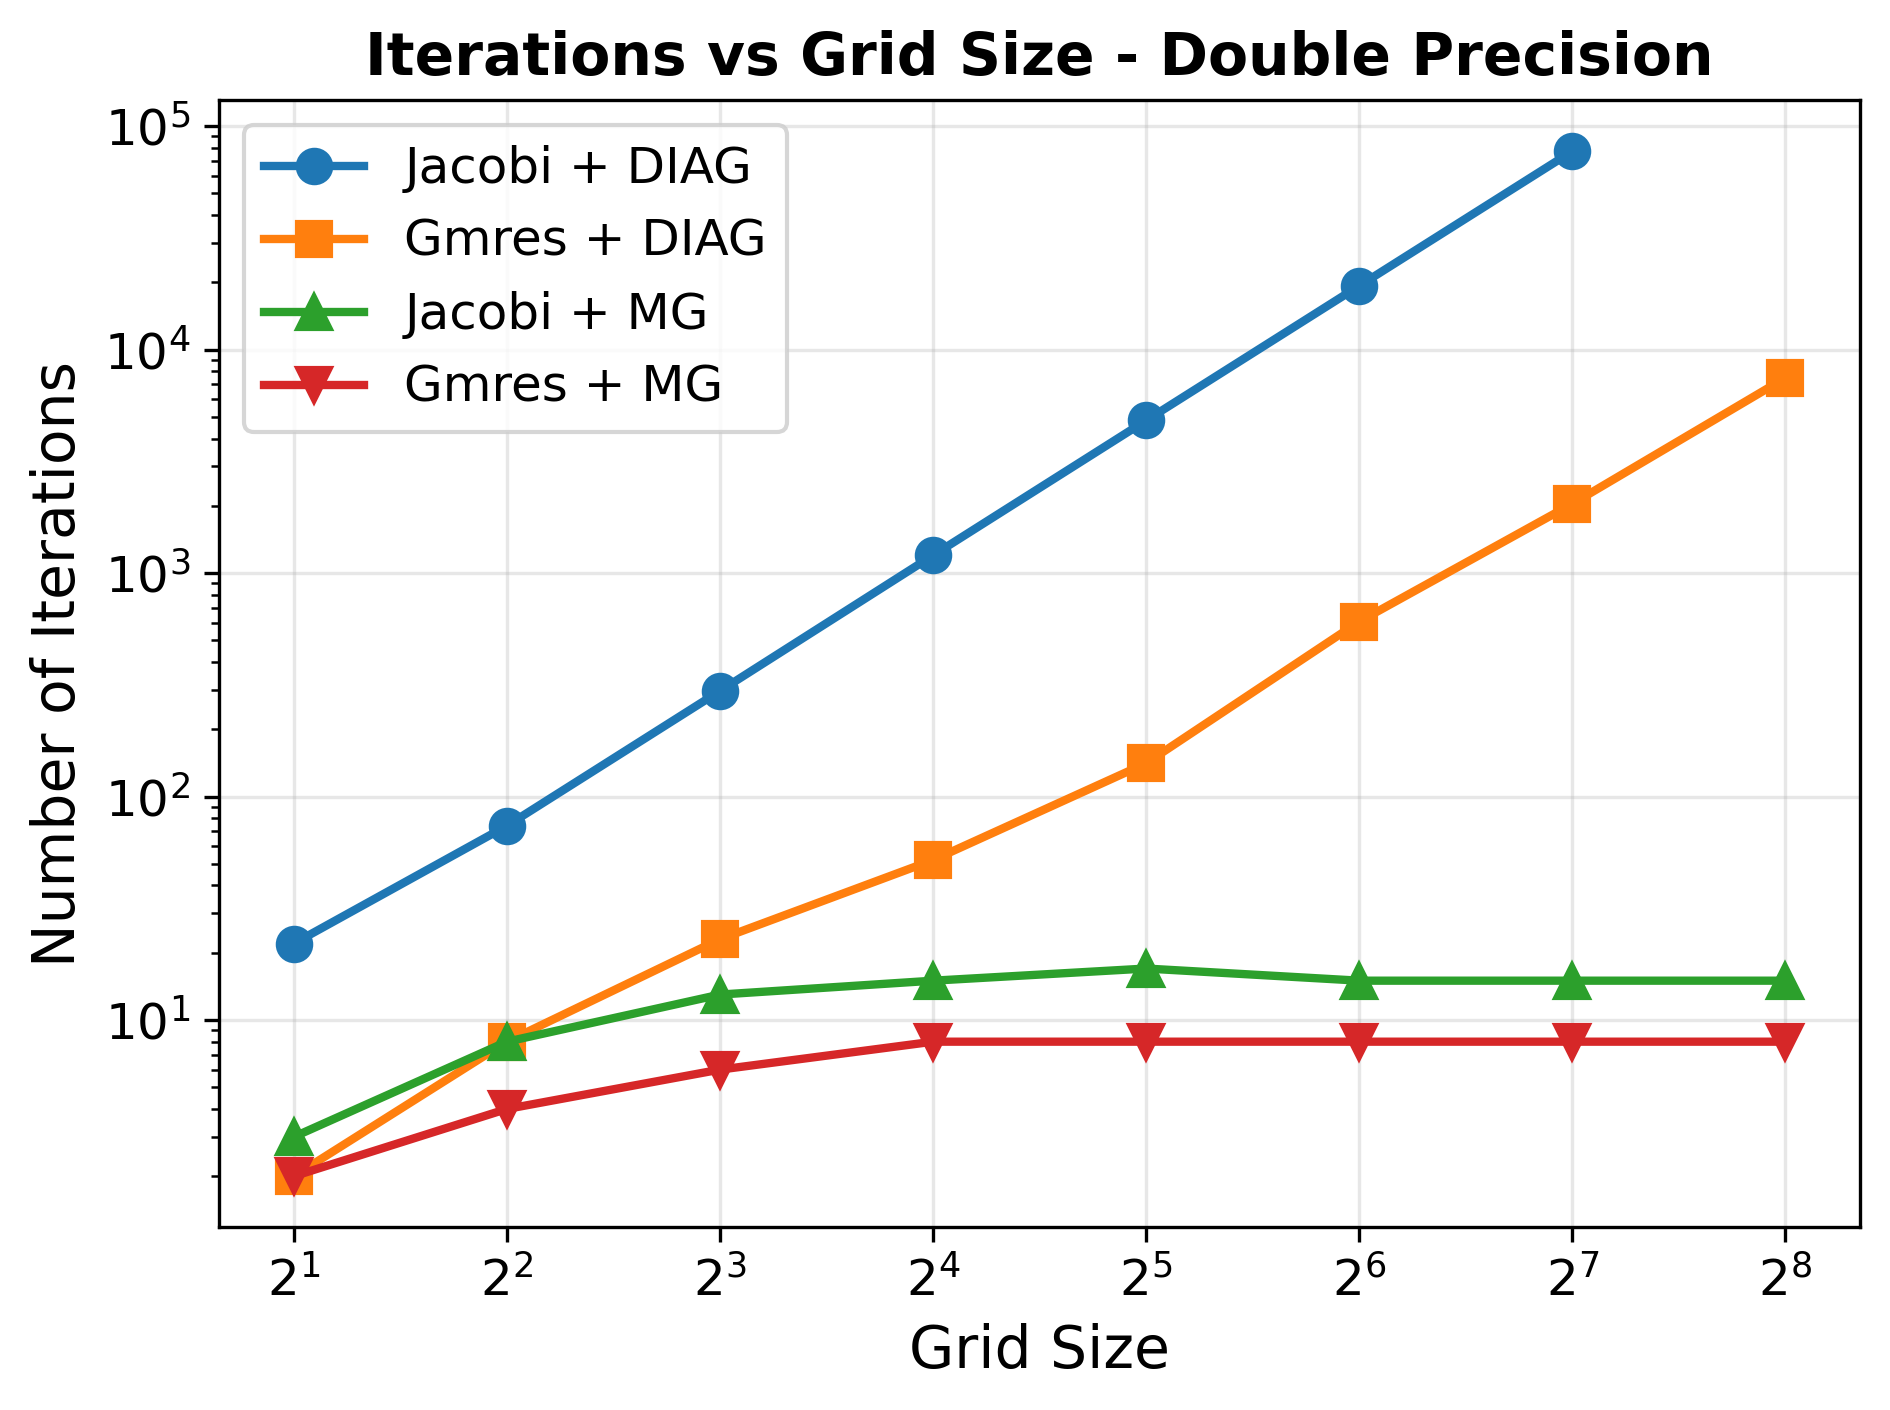

In [4]:
# Define markers and colors for different configurations
markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h', 'X', 'P']
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Create plots for each precision type
for precision in ['float', 'double']:
    scale = 0.8
    fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

    # Prepare data for plotting
    plot_data = []
    for key, dtype_dict in grid_size_dict.items():
        solver, prec, arch = key

        # Check if this precision exists
        if precision not in dtype_dict:
            continue

        grid_sizes = sorted(dtype_dict[precision].keys())
        iterations = [dtype_dict[precision][size] for size in grid_sizes]

        # Calculate maximum iterations for sorting
        max_iterations = max(iterations) if iterations else 0

        # Create label
        label = f"{solver.capitalize()} + {prec.upper()}"

        plot_data.append((key, grid_sizes, iterations, max_iterations, label))

    # Sort by maximum iterations (descending - most iterations first in legend)
    plot_data.sort(key=lambda x: x[3], reverse=True)

    marker_idx = 0
    for key, grid_sizes, iterations, max_iterations, label in plot_data:
        # Get marker and color
        marker = markers[marker_idx % len(markers)]
        color = colors[marker_idx % len(colors)]
        marker_idx += 1

        # Plot with markers
        ax.plot(
            grid_sizes, iterations,
            marker=marker,
            color=color,
            label=label,
            markersize=8,
            linewidth=2
        )

    ax.set_xlabel('Grid Size', fontsize=14)
    ax.set_ylabel('Number of Iterations', fontsize=14)
    ax.set_title(f'Iterations vs Grid Size - {precision.capitalize()} Precision', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)

    y_ticks = [10**0, 10**1, 10**2, 10**3, 10**4]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'$10^{{{int(np.log10(t))}}}$' for t in y_ticks], fontsize=12)

    # Set log scale on x-axis (base 2)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=10)

    # Format ticks
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=12)

    plt.tight_layout()
    plt.show()

---

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('results.csv')
df.head()

,solver,prec,arch,cores,size,iters_n(float),time(float),reduction_rate(float),iters_n(double),time(double),reduction_rate(double)
0,gmres,diag,cpu,1,256,0,298942.085000,0.0,0,276043.279000,0.0
1,gmres,diag,cuda,1,256,0,1682.175903,0.0,0,4534.665039,0.0
2,gmres,diag,omp,2,256,0,697797.021000,0.0,0,843743.245000,0.0
3,gmres,diag,omp,4,256,0,338835.432000,0.0,0,421637.624000,0.0
4,gmres,diag,omp,8,256,0,163063.726000,0.0,0,211455.319000,0.0


In [8]:
df[(df.solver=='jacobi') & (df.prec=='mg')]

,solver,prec,arch,cores,size,iters_n(float),time(float),reduction_rate(float),iters_n(double),time(double),reduction_rate(double)
24,jacobi,mg,cpu,1,256,0,1.851470e+06,0.0,0,287458.551000,0.0
25,jacobi,mg,cuda,1,256,0,2.041135e+03,0.0,0,1188.884155,0.0
26,jacobi,mg,omp,2,256,0,1.263494e+06,0.0,0,342049.731000,0.0
27,jacobi,mg,omp,4,256,0,6.337848e+05,0.0,0,171276.739000,0.0
28,jacobi,mg,omp,8,256,0,3.177867e+05,0.0,0,85851.730000,0.0
29,jacobi,mg,omp,16,256,0,1.613676e+05,0.0,0,43560.550000,0.0
30,jacobi,mg,omp,32,256,0,8.499515e+04,0.0,0,22837.541000,0.0
31,jacobi,mg,omp,64,256,0,5.613171e+04,0.0,0,14419.192000,0.0
